In [2]:
import math
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.style as style
import numpy as np
import pandas as pd

import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency, f_oneway
import datetime
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.ensemble import VotingRegressor
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# 연관분석 라이브러리
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder
import itertools

In [3]:
# 데이터 시각화
import matplotlib.pyplot as plt
import matplotlib

# 맑은 고딕 적용
matplotlib.rc("font", family = "AppleGothic")
# 음수 표시
matplotlib.rc("axes", unicode_minus = False)

In [4]:
df = pd.read_csv("../df_merged.csv", encoding="cp949")
df.head()

,idUser,idOrder,OrderDT,ItemCode,Price,DeliveryDT,OrderYear,OrderMonth,OrderDay,OrderHour,...,ItemSmallCode,ItemSmallName,ItemName,PriceMin,PriceMax,Gender,Age,FamilyCount,MemberYN,AgeGroup
0,U10001,U10001-O2023-1002,2023-01-06 17:08:51,L4-M17-S0530-1024,33310,2023-01-07 06:24:00,2023,1,6,17,...,S0530,전복,완도 활전복 1kg 중 22-25미,33160.0,37070.0,여성,26,2,Y,20
1,U10001,U10001-O2023-1002,2023-01-06 17:08:51,L1-M21-S0540-1082,3780,2023-01-07 06:24:00,2023,1,6,17,...,S0540,즉석,동원 양반 차돌된장찌개 (460G),3690.0,3970.0,여성,26,2,Y,20
2,U10001,U10001-O2023-1002,2023-01-06 17:08:51,L1-M15-S0140-1311,22520,2023-01-07 06:24:00,2023,1,6,17,...,S0140,냉동,오뚜기 듬뿍 새우볶음밥450g (2인분) x 5봉지 /,22150.0,23150.0,여성,26,2,Y,20
3,U10001,U10001-O2023-1002,2023-01-06 17:08:51,L4-M12-S0350-1035,21630,2023-01-07 06:24:00,2023,1,6,17,...,S0350,사과,[산지직송] 새콤달콤 부사 사과 5kg (13과내),20810.0,23030.0,여성,26,2,Y,20
4,U10001,U10001-O2023-1003,2023-01-13 16:50:14,L4-M12-S0640-1057,11700,2023-01-14 06:28:00,2023,1,13,16,...,S0640,토마토,스테비아 방울 토마토 라루 토망고 1kg,11640.0,13020.0,여성,26,2,Y,20


In [5]:
df = df.dropna()

In [6]:
# =============================================
# Step 1: 데이터 준비 - 기준일 설정 및 기간 필터링
# =============================================

# OrderDT를 datetime으로 변환
df['OrderDT'] = pd.to_datetime(df['OrderDT'])

# 기준일: 데이터 최대일 + 1일
snapshot_date = pd.Timestamp('2025-12-30')

# 최근 3개월(분기) 필터링
start_date = pd.Timestamp('2025-10-01')
df_rfm = df[(df['OrderDT'] >= start_date) & (df['OrderDT'] <= snapshot_date)].copy()

print(f"전체 데이터: {len(df):,}건")
print(f"분석 기간: {start_date.date()} ~ {snapshot_date.date()}")
print(f"필터링 후: {len(df_rfm):,}건")
print(f"대상 고객 수: {df_rfm['idUser'].nunique():,}명")
print(f"대상 주문 수: {df_rfm['idOrder'].nunique():,}건")

전체 데이터: 854,101건
분석 기간: 2025-10-01 ~ 2025-12-30
필터링 후: 90,768건
대상 고객 수: 2,976명
대상 주문 수: 15,510건


# CV기반 가중치 적용

In [7]:
# =============================================
# Step 2: 전체 데이터 기반 CV 가중치 산출
# =============================================
# 가중치(어떤 지표가 중요한가)는 전체 3년 데이터에서 결정

rfm_full = df.groupby('idUser').agg(
    Recency=('OrderDT', lambda x: (snapshot_date - x.max()).days),
    Frequency=('idOrder', 'nunique'),
    Monetary=('Price', 'sum')
).reset_index()

# 전체 데이터 CV → 가중치
cv_r_full = rfm_full['Recency'].std() / rfm_full['Recency'].mean()
cv_f_full = rfm_full['Frequency'].std() / rfm_full['Frequency'].mean()
cv_m_full = rfm_full['Monetary'].std() / rfm_full['Monetary'].mean()

total_cv_full = cv_r_full + cv_f_full + cv_m_full
w_r = cv_r_full / total_cv_full
w_f = cv_f_full / total_cv_full
w_m = cv_m_full / total_cv_full

# 3개월 데이터 CV (비교용)
cv_r_3m = rfm['Recency'].std() / rfm['Recency'].mean()
cv_f_3m = rfm['Frequency'].std() / rfm['Frequency'].mean()
cv_m_3m = rfm['Monetary'].std() / rfm['Monetary'].mean()

print("=== CV 비교: 전체(3년) vs 3개월 ===")
print(f"{'지표':<12} {'전체 CV':>10} {'3개월 CV':>10}")
print("-" * 34)
print(f"{'Recency':<12} {cv_r_full:>10.4f} {cv_r_3m:>10.4f}")
print(f"{'Frequency':<12} {cv_f_full:>10.4f} {cv_f_3m:>10.4f}")
print(f"{'Monetary':<12} {cv_m_full:>10.4f} {cv_m_3m:>10.4f}")

print(f"\n=== 전체 데이터 기반 최종 가중치 ===")
print(f"{'지표':<12} {'가중치':>8}")
print("-" * 22)
print(f"{'Recency':<12} {w_r:>8.4f}")
print(f"{'Frequency':<12} {w_f:>8.4f}")
print(f"{'Monetary':<12} {w_m:>8.4f}")
print("-" * 22)
print(f"{'합계':<12} {w_r+w_f+w_m:>8.4f}")

NameError: name 'rfm' is not defined

In [ ]:
# =============================================
# Step 2: RFM 지표 계산
# =============================================

rfm = df_rfm.groupby('idUser').agg(
    Recency=('OrderDT', lambda x: (snapshot_date - x.max()).days),
    Frequency=('idOrder', 'nunique'),
    Monetary=('Price', 'sum')
).reset_index()

print("=== RFM 기술통계량 ===")
print(rfm[['Recency', 'Frequency', 'Monetary']].describe().round(2))
print(f"\n분석 대상 고객 수: {len(rfm):,}명")

=== RFM 기술통계량 ===
       Recency  Frequency    Monetary
count  2976.00    2976.00     2976.00
mean     15.55       5.21   485487.06
std      16.10       2.25   226110.63
min       0.00       1.00     9050.00
25%       4.00       4.00   323555.00
50%      11.00       5.00   465460.00
75%      21.00       7.00   626145.00
max      89.00      14.00  1417860.00

분석 대상 고객 수: 2,976명


In [ ]:
# =============================================
# Step 3: RFM 점수 부여 (1~4점, 4분위수 기반)
# =============================================

# R: 낮을수록(최근) 좋으므로 역순
rfm['R_score'] = pd.qcut(rfm['Recency'], q=4, labels=[4, 3, 2, 1], duplicates='drop').astype(int)

# F: 높을수록 좋으므로 정순
rfm['F_score'] = pd.qcut(rfm['Frequency'], q=4, labels=[1, 2, 3, 4], duplicates='drop').astype(int)

# M: 높을수록 좋으므로 정순
rfm['M_score'] = pd.qcut(rfm['Monetary'], q=4, labels=[1, 2, 3, 4], duplicates='drop').astype(int)

print("=== RFM 점수 분포 ===")
for col in ['R_score', 'F_score', 'M_score']:
    print(f"\n{col}:")
    print(rfm[col].value_counts().sort_index())

=== RFM 점수 분포 ===

R_score:
R_score
1    715
2    678
3    792
4    791
Name: count, dtype: int64

F_score:
F_score
1    1201
2     499
3     825
4     451
Name: count, dtype: int64

M_score:
M_score
1    744
2    745
3    743
4    744
Name: count, dtype: int64


In [ ]:
# =============================================
# Step 5: 전체 CV 가중치 적용 및 등급 분류
# =============================================
# 가중치(w_r, w_f, w_m)는 Step 2에서 전체 데이터 기반으로 산출됨

# 가중 점수 계산
rfm['weighted_score'] = rfm['R_score'] * w_r + rfm['F_score'] * w_f + rfm['M_score'] * w_m

# 4분위로 등급 분류
rfm['Grade'] = pd.qcut(rfm['weighted_score'], q=4, labels=['Bronze', 'Silver', 'Gold', 'VIP'], duplicates='drop')

print(f"=== 적용된 가중치 (전체 데이터 CV 기반) ===")
print(f"R: {w_r:.4f}, F: {w_f:.4f}, M: {w_m:.4f}")

print(f"\n=== 회원등급 분포 ===")
print(rfm['Grade'].value_counts().sort_index())

print(f"\n=== 등급별 RFM 평균 ===")
print(rfm.groupby('Grade', observed=True)[['Recency', 'Frequency', 'Monetary', 'weighted_score']].mean().round(2))

=== 적용된 가중치 (전체 데이터 CV 기반) ===
R: 0.7103, F: 0.1452, M: 0.1444

=== 회원등급 분포 ===
Grade
Bronze    812
Silver    732
Gold      688
VIP       744
Name: count, dtype: int64

=== 등급별 RFM 평균 ===
        Recency  Frequency   Monetary  weighted_score
Grade                                                
Bronze    35.33       3.27  294417.32            1.25
Silver    14.15       4.76  452684.80            2.21
Gold       7.38       5.61  520994.52            2.95
VIP        2.91       7.41  693458.49            3.71


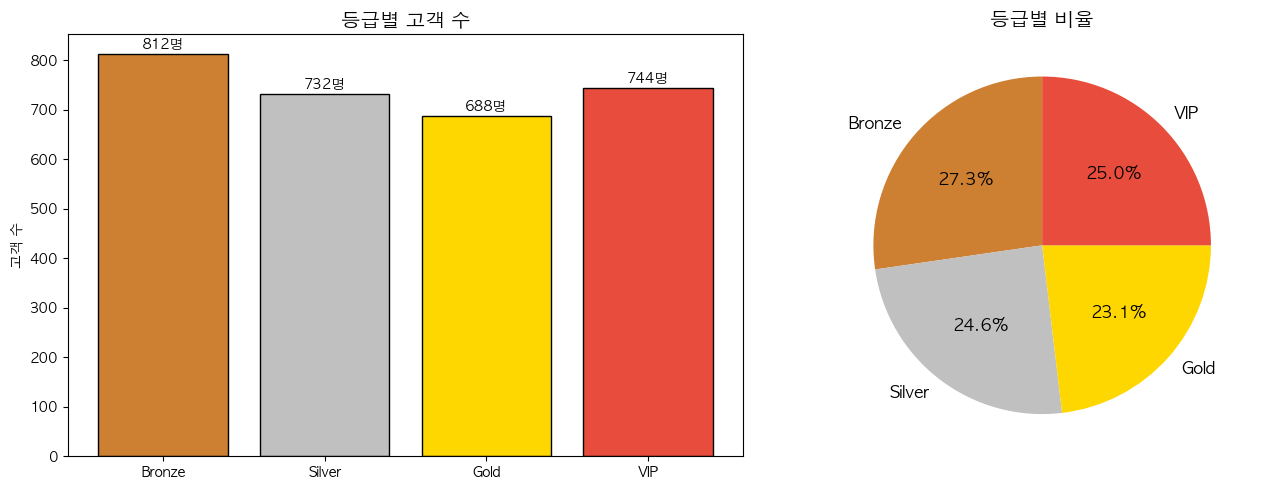

In [ ]:
# =============================================
# Step 5-1: 시각화 - 등급별 고객 수 분포
# =============================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 등급별 고객 수
grade_counts = rfm['Grade'].value_counts().sort_index()
colors = ['#cd7f32', '#c0c0c0', '#ffd700', '#e74c3c']
axes[0].bar(grade_counts.index, grade_counts.values, color=colors, edgecolor='black')
axes[0].set_title('등급별 고객 수', fontsize=14, fontweight='bold')
axes[0].set_ylabel('고객 수')
for i, v in enumerate(grade_counts.values):
    axes[0].text(i, v + 10, f'{v}명', ha='center', fontweight='bold')

# 등급별 비율 파이차트
axes[1].pie(grade_counts.values, labels=grade_counts.index, colors=colors,
            autopct='%1.1f%%', startangle=90, textprops={'fontsize': 12})
axes[1].set_title('등급별 비율', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('rfm_grade_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

/var/folders/cg/m63vxzr11690z4xpkx8d511r0000gn/T/ipykernel_30534/3785382129.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  means = rfm.groupby('Grade')[col].mean().reindex(grade_order)
/var/folders/cg/m63vxzr11690z4xpkx8d511r0000gn/T/ipykernel_30534/3785382129.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  means = rfm.groupby('Grade')[col].mean().reindex(grade_order)
/var/folders/cg/m63vxzr11690z4xpkx8d511r0000gn/T/ipykernel_30534/3785382129.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain cur

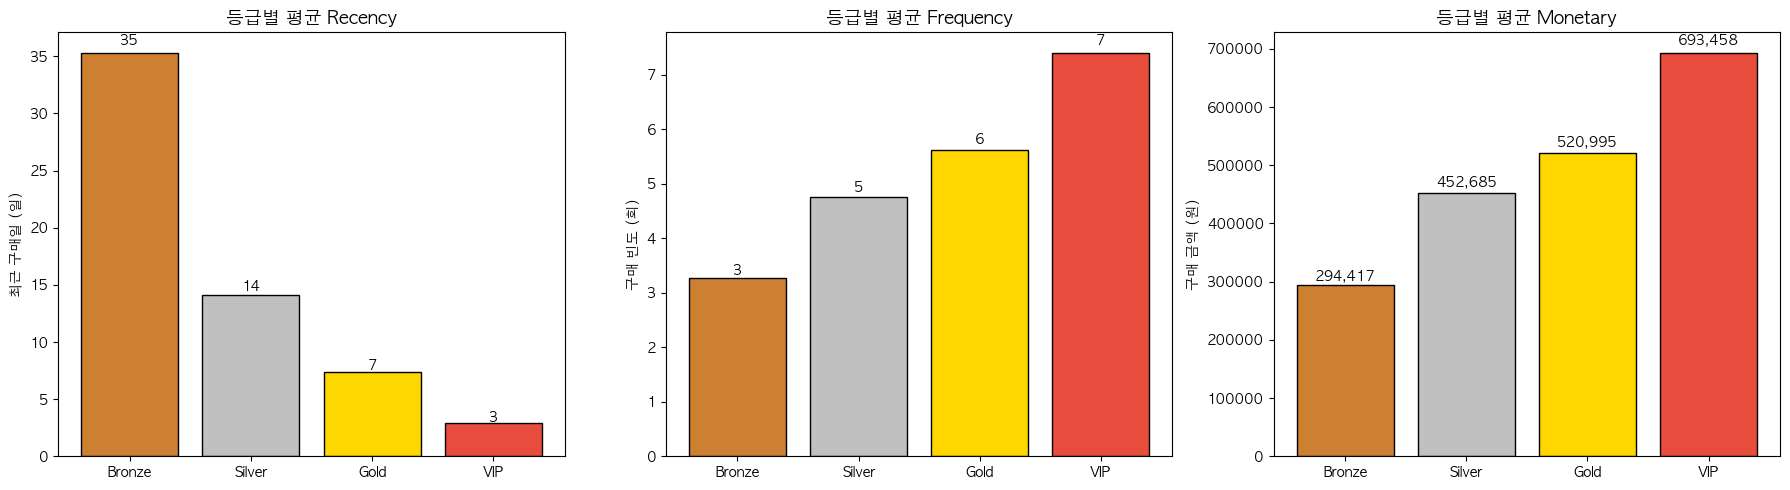

In [ ]:
# =============================================
# Step 5-2: 시각화 - 등급별 R, F, M 평균 비교
# =============================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
grade_order = ['Bronze', 'Silver', 'Gold', 'VIP']
colors = ['#cd7f32', '#c0c0c0', '#ffd700', '#e74c3c']

metrics = [('Recency', '최근 구매일 (일)', True), 
           ('Frequency', '구매 빈도 (회)', False), 
           ('Monetary', '구매 금액 (원)', False)]

for ax, (col, ylabel, reverse) in zip(axes, metrics):
    means = rfm.groupby('Grade')[col].mean().reindex(grade_order)
    bars = ax.bar(grade_order, means.values, color=colors, edgecolor='black')
    ax.set_title(f'등급별 평균 {col}', fontsize=13, fontweight='bold')
    ax.set_ylabel(ylabel)
    for bar, val in zip(bars, means.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + bar.get_height()*0.02,
                f'{val:,.0f}', ha='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig('rfm_grade_rfm_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

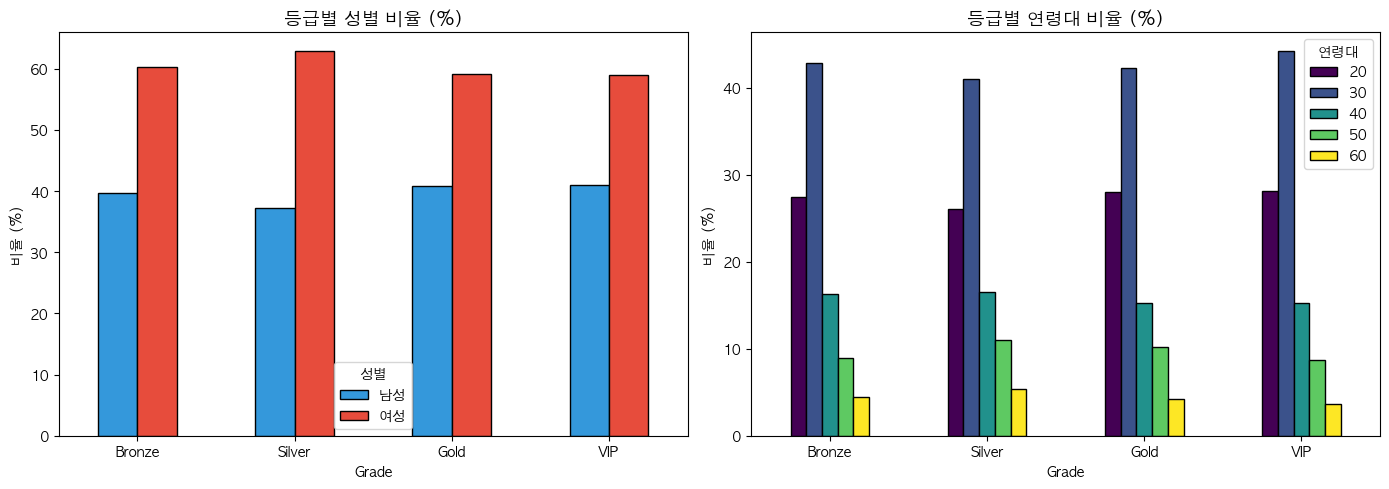

=== 등급별 성별 비율 (%) ===
Gender    남성    여성
Grade             
Bronze  39.7  60.3
Silver  37.2  62.8
Gold    40.8  59.2
VIP     41.0  59.0

=== 등급별 연령대 비율 (%) ===
AgeGroup    20    30    40    50   60
Grade                                
Bronze    27.5  42.9  16.3   9.0  4.4
Silver    26.1  41.0  16.5  11.1  5.3
Gold      28.1  42.3  15.3  10.2  4.2
VIP       28.1  44.2  15.3   8.7  3.6


In [ ]:
# =============================================
# Step 5-3: 시각화 - 등급별 인구통계 특성
# =============================================

# 고객 인구통계 정보 병합 (고객별 첫 번째 레코드 사용)
customer_info = df_rfm.groupby('idUser').agg(
    Gender=('Gender', 'first'),
    AgeGroup=('AgeGroup', 'first')
).reset_index()

rfm_demo = rfm.merge(customer_info, on='idUser')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 등급별 성별 분포
ct_gender = pd.crosstab(rfm_demo['Grade'], rfm_demo['Gender'], normalize='index') * 100
ct_gender = ct_gender.reindex(grade_order)
ct_gender.plot(kind='bar', ax=axes[0], color=['#3498db', '#e74c3c'], edgecolor='black')
axes[0].set_title('등급별 성별 비율 (%)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('비율 (%)')
axes[0].set_xticklabels(grade_order, rotation=0)
axes[0].legend(title='성별')

# 등급별 연령대 분포
ct_age = pd.crosstab(rfm_demo['Grade'], rfm_demo['AgeGroup'], normalize='index') * 100
ct_age = ct_age.reindex(grade_order)
ct_age.plot(kind='bar', ax=axes[1], colormap='viridis', edgecolor='black')
axes[1].set_title('등급별 연령대 비율 (%)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('비율 (%)')
axes[1].set_xticklabels(grade_order, rotation=0)
axes[1].legend(title='연령대')

plt.tight_layout()
plt.savefig('rfm_grade_demographics.png', dpi=150, bbox_inches='tight')
plt.show()

# 크로스탭 출력
print("=== 등급별 성별 비율 (%) ===")
print(ct_gender.round(1))
print(f"\n=== 등급별 연령대 비율 (%) ===")
print(ct_age.round(1))

In [ ]:
# =============================================
# Step 6: 결과 저장
# =============================================

# CSV 저장
rfm.to_csv('../customer_rfm.csv', index=False, encoding='cp949')
print(f"RFM 결과 저장 완료: customer_rfm.csv ({len(rfm):,}명)")
print(f"\n=== 저장된 컬럼 ===")
print(rfm.columns.tolist())
print(f"\n=== 최종 결과 미리보기 ===")
rfm.head(10)

RFM 결과 저장 완료: customer_rfm.csv (2,976명)

=== 저장된 컬럼 ===
['idUser', 'Recency', 'Frequency', 'Monetary', 'R_score', 'F_score', 'M_score', 'weighted_score', 'Grade']

=== 최종 결과 미리보기 ===


,idUser,Recency,Frequency,Monetary,R_score,F_score,M_score,weighted_score,Grade
0,U10001,4,6,440400,4,3,2,3.565901,VIP
1,U10002,25,3,381660,1,1,2,1.144432,Bronze
2,U10003,8,3,268270,3,1,1,2.420665,Silver
3,U10004,26,2,156410,1,1,1,1.000000,Bronze
4,U10005,41,5,382380,1,2,2,1.289668,Bronze
5,U10006,4,6,595660,4,3,3,3.710332,VIP
6,U10007,31,4,425410,1,1,2,1.144432,Bronze
7,U10008,5,4,259330,3,1,1,2.420665,Silver
8,U10009,19,2,216590,2,1,1,1.710332,Bronze
9,U10010,2,4,276810,4,1,1,3.130997,Gold


# 수동 가중치 ( 0.35, 0.45, 0.2)

In [ ]:
# =============================================
# 수동 가중치 적용: R=0.35, F=0.45, M=0.2
# =============================================

w_r_manual = 0.35
w_f_manual = 0.45
w_m_manual = 0.20

rfm['weighted_score_manual'] = (
    rfm['R_score'] * w_r_manual + 
    rfm['F_score'] * w_f_manual + 
    rfm['M_score'] * w_m_manual
)

rfm['Grade_manual'] = pd.qcut(
    rfm['weighted_score_manual'], q=4, 
    labels=['Bronze', 'Silver', 'Gold', 'VIP'], duplicates='drop'
)

print(f"=== 수동 가중치: R={w_r_manual}, F={w_f_manual}, M={w_m_manual} ===")

print(f"\n=== 회원등급 분포 ===")
print(rfm['Grade_manual'].value_counts().sort_index())

print(f"\n=== 등급별 RFM 평균 ===")
print(rfm.groupby('Grade_manual', observed=True)[['Recency', 'Frequency', 'Monetary', 'weighted_score_manual']].mean().round(2))

=== 수동 가중치: R=0.35, F=0.45, M=0.2 ===

=== 회원등급 분포 ===
Grade_manual
Bronze    770
Silver    805
Gold      704
VIP       697
Name: count, dtype: int64

=== 등급별 RFM 평균 ===
              Recency  Frequency   Monetary  weighted_score_manual
Grade_manual                                                      
Bronze          33.51       2.91  269782.39                   1.20
Silver          12.33       4.21  378884.31                   2.01
Gold            10.40       6.09  577441.76                   2.84
VIP              4.64       8.03  754026.07                   3.63


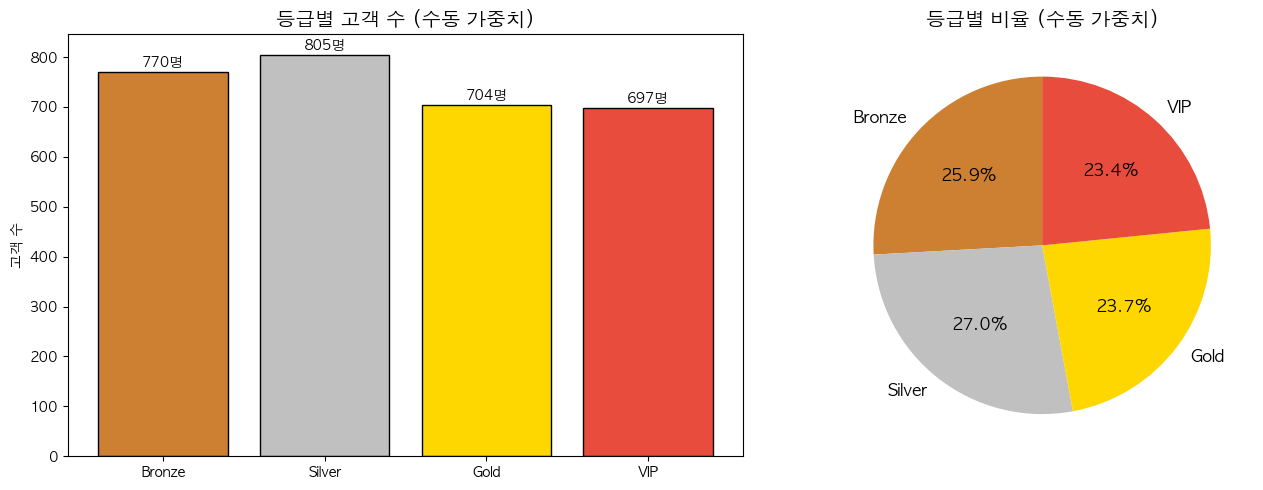

In [ ]:
# =============================================
# 시각화 - 수동 가중치 등급별 고객 수 분포
# =============================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

grade_counts_manual = rfm['Grade_manual'].value_counts().sort_index()
colors = ['#cd7f32', '#c0c0c0', '#ffd700', '#e74c3c']

axes[0].bar(grade_counts_manual.index, grade_counts_manual.values, color=colors, edgecolor='black')
axes[0].set_title('등급별 고객 수 (수동 가중치)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('고객 수')
for i, v in enumerate(grade_counts_manual.values):
    axes[0].text(i, v + 10, f'{v}명', ha='center', fontweight='bold')

axes[1].pie(grade_counts_manual.values, labels=grade_counts_manual.index, colors=colors,
            autopct='%1.1f%%', startangle=90, textprops={'fontsize': 12})
axes[1].set_title('등급별 비율 (수동 가중치)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('rfm_manual_grade_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

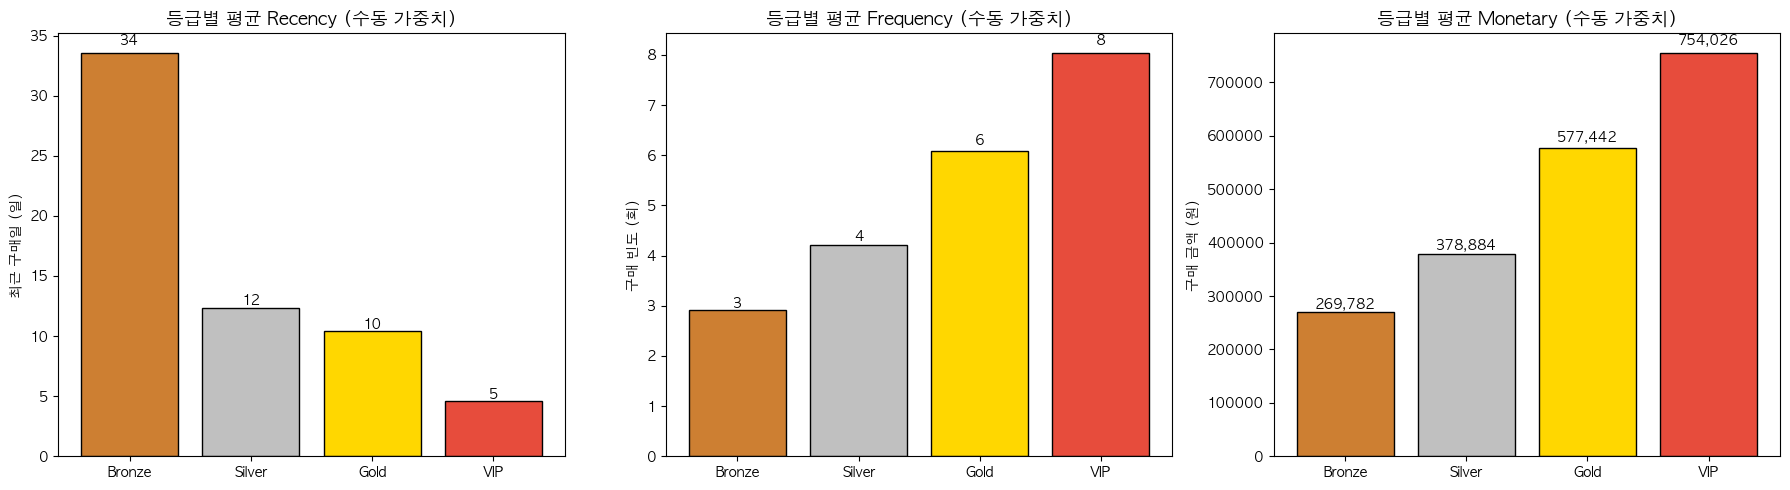

In [ ]:
# =============================================
# 시각화 - 수동 가중치 등급별 R, F, M 평균 비교
# =============================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
grade_order = ['Bronze', 'Silver', 'Gold', 'VIP']
colors = ['#cd7f32', '#c0c0c0', '#ffd700', '#e74c3c']

metrics = [('Recency', '최근 구매일 (일)'), 
           ('Frequency', '구매 빈도 (회)'), 
           ('Monetary', '구매 금액 (원)')]

for ax, (col, ylabel) in zip(axes, metrics):
    means = rfm.groupby('Grade_manual', observed=True)[col].mean().reindex(grade_order)
    bars = ax.bar(grade_order, means.values, color=colors, edgecolor='black')
    ax.set_title(f'등급별 평균 {col} (수동 가중치)', fontsize=13, fontweight='bold')
    ax.set_ylabel(ylabel)
    for bar, val in zip(bars, means.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + bar.get_height()*0.02,
                f'{val:,.0f}', ha='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig('rfm_manual_grade_rfm_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

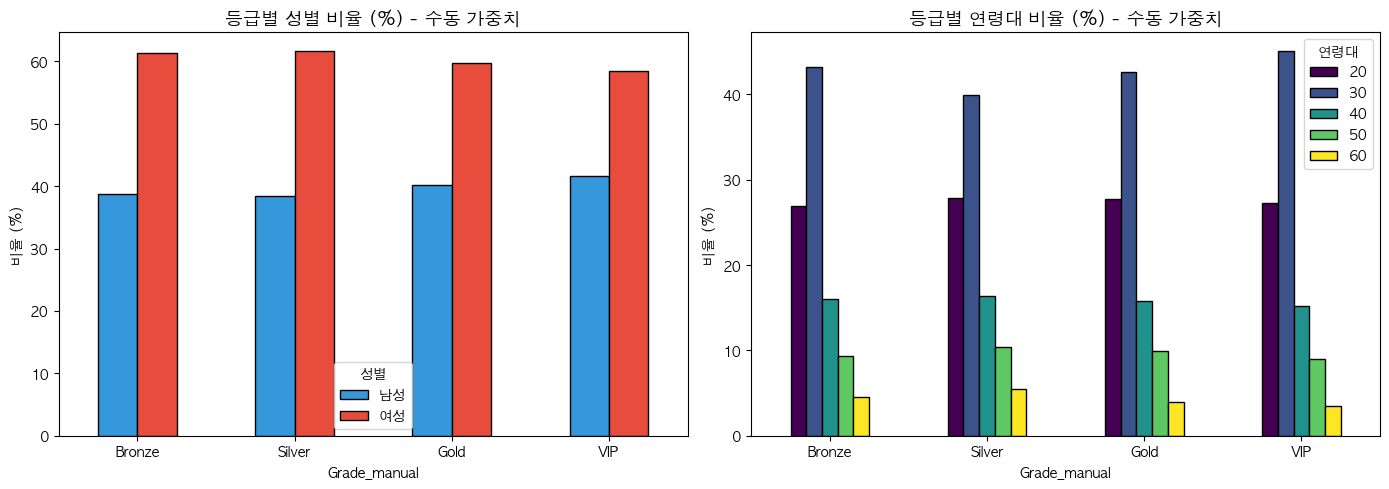

=== 등급별 성별 비율 (%) ===
Gender          남성    여성
Grade_manual            
Bronze        38.7  61.3
Silver        38.4  61.6
Gold          40.2  59.8
VIP           41.6  58.4

=== 등급별 연령대 비율 (%) ===
AgeGroup        20    30    40    50   60
Grade_manual                             
Bronze        26.9  43.2  16.0   9.4  4.5
Silver        27.8  39.9  16.4  10.4  5.5
Gold          27.7  42.6  15.8   9.9  4.0
VIP           27.3  45.1  15.2   9.0  3.4


In [ ]:
# =============================================
# 시각화 - 수동 가중치 등급별 인구통계 특성
# =============================================

rfm_demo_manual = rfm.merge(customer_info, on='idUser')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ct_gender_m = pd.crosstab(rfm_demo_manual['Grade_manual'], rfm_demo_manual['Gender'], normalize='index') * 100
ct_gender_m = ct_gender_m.reindex(grade_order)
ct_gender_m.plot(kind='bar', ax=axes[0], color=['#3498db', '#e74c3c'], edgecolor='black')
axes[0].set_title('등급별 성별 비율 (%) - 수동 가중치', fontsize=13, fontweight='bold')
axes[0].set_ylabel('비율 (%)')
axes[0].set_xticklabels(grade_order, rotation=0)
axes[0].legend(title='성별')

ct_age_m = pd.crosstab(rfm_demo_manual['Grade_manual'], rfm_demo_manual['AgeGroup'], normalize='index') * 100
ct_age_m = ct_age_m.reindex(grade_order)
ct_age_m.plot(kind='bar', ax=axes[1], colormap='viridis', edgecolor='black')
axes[1].set_title('등급별 연령대 비율 (%) - 수동 가중치', fontsize=13, fontweight='bold')
axes[1].set_ylabel('비율 (%)')
axes[1].set_xticklabels(grade_order, rotation=0)
axes[1].legend(title='연령대')

plt.tight_layout()
plt.savefig('rfm_manual_grade_demographics.png', dpi=150, bbox_inches='tight')
plt.show()

print("=== 등급별 성별 비율 (%) ===")
print(ct_gender_m.round(1))
print(f"\n=== 등급별 연령대 비율 (%) ===")
print(ct_age_m.round(1))

In [ ]:
# =============================================
# 수동 가중치 결과 저장
# =============================================

rfm.to_csv('../customer_rfm.csv', index=False, encoding='cp949')
print(f"RFM 결과 저장 완료: customer_rfm.csv ({len(rfm):,}명)")
print(f"\n=== 저장된 컬럼 ===")
print(rfm.columns.tolist())
print(f"\n=== 최종 결과 미리보기 ===")
rfm[['idUser', 'Recency', 'Frequency', 'Monetary', 'R_score', 'F_score', 'M_score', 
     'weighted_score_manual', 'Grade_manual']].head(10)

RFM 결과 저장 완료: customer_rfm.csv (2,976명)

=== 저장된 컬럼 ===
['idUser', 'Recency', 'Frequency', 'Monetary', 'R_score', 'F_score', 'M_score', 'weighted_score', 'Grade', 'weighted_score_manual', 'Grade_manual']

=== 최종 결과 미리보기 ===


,idUser,Recency,Frequency,Monetary,R_score,F_score,M_score,weighted_score_manual,Grade_manual
0,U10001,4,6,440400,4,3,2,3.15,Gold
1,U10002,25,3,381660,1,1,2,1.20,Bronze
2,U10003,8,3,268270,3,1,1,1.70,Silver
3,U10004,26,2,156410,1,1,1,1.00,Bronze
4,U10005,41,5,382380,1,2,2,1.65,Silver
5,U10006,4,6,595660,4,3,3,3.35,VIP
6,U10007,31,4,425410,1,1,2,1.20,Bronze
7,U10008,5,4,259330,3,1,1,1.70,Silver
8,U10009,19,2,216590,2,1,1,1.35,Bronze
9,U10010,2,4,276810,4,1,1,2.05,Silver


# 전체 기간(3년) + 수동 가중치 (R=0.35, F=0.45, M=0.2) — 5점 체계, 4등급

In [ ]:
# =============================================
# 전체 기간 RFM 지표 계산 (3년)
# =============================================

rfm_all = df.groupby('idUser').agg(
    Recency=('OrderDT', lambda x: (snapshot_date - x.max()).days),
    Frequency=('idOrder', 'nunique'),
    Monetary=('Price', 'sum')
).reset_index()

print(f"=== 전체 기간 RFM 기술통계량 (3년) ===")
print(f"분석 대상 고객 수: {len(rfm_all):,}명")
print(f"분석 기간: {df['OrderDT'].min().date()} ~ {df['OrderDT'].max().date()}\n")
print(rfm_all[['Recency', 'Frequency', 'Monetary']].describe().round(2))

=== 전체 기간 RFM 기술통계량 (3년) ===
분석 대상 고객 수: 3,000명
분석 기간: 2023-01-02 ~ 2025-12-29

       Recency  Frequency    Monetary
count  3000.00    3000.00     3000.00
mean     16.30      57.01  4388287.82
std      18.16      12.99   994365.45
min       0.00       9.00   792360.00
25%       4.00      49.00  3739295.00
50%      11.00      60.00  4459500.00
75%      21.00      66.00  5081795.00
max     193.00      90.00  7432080.00


In [ ]:
# =============================================
# RFM 점수 부여 (1~5점, 5분위수 기반)
# =============================================

# R: 낮을수록(최근) 좋으므로 역순
rfm_all['R_score'] = pd.qcut(rfm_all['Recency'], q=5, labels=[5, 4, 3, 2, 1], duplicates='drop').astype(int)

# F: 높을수록 좋으므로 정순
rfm_all['F_score'] = pd.qcut(rfm_all['Frequency'], q=5, labels=[1, 2, 3, 4, 5], duplicates='drop').astype(int)

# M: 높을수록 좋으므로 정순
rfm_all['M_score'] = pd.qcut(rfm_all['Monetary'], q=5, labels=[1, 2, 3, 4, 5], duplicates='drop').astype(int)

print("=== RFM 점수 분포 (전체 기간, 5점 체계) ===")
for col in ['R_score', 'F_score', 'M_score']:
    print(f"\n{col}:")
    print(rfm_all[col].value_counts().sort_index())

=== RFM 점수 분포 (전체 기간, 5점 체계) ===

R_score:
R_score
1    545
2    648
3    561
4    645
5    601
Name: count, dtype: int64

F_score:
F_score
1    645
2    586
3    605
4    620
5    544
Name: count, dtype: int64

M_score:
M_score
1    600
2    600
3    601
4    599
5    600
Name: count, dtype: int64


In [ ]:
# =============================================
# 수동 가중치 적용 및 등급 분류 (5점→4등급)
# =============================================

w_r_all = 0.35
w_f_all = 0.45
w_m_all = 0.20

# 가중 점수 (범위: 1.0 ~ 5.0)
rfm_all['weighted_score'] = (
    rfm_all['R_score'] * w_r_all + 
    rfm_all['F_score'] * w_f_all + 
    rfm_all['M_score'] * w_m_all
)

# 가중 점수를 4분위로 나눠 4등급 분류
rfm_all['Grade'] = pd.qcut(
    rfm_all['weighted_score'], q=4, 
    labels=['Bronze', 'Silver', 'Gold', 'VIP'], duplicates='drop'
)

print(f"=== 수동 가중치: R={w_r_all}, F={w_f_all}, M={w_m_all} (5점 체계 → 4등급) ===")
print(f"가중 점수 범위: {rfm_all['weighted_score'].min():.2f} ~ {rfm_all['weighted_score'].max():.2f}")

print(f"\n=== 회원등급 분포 (전체 기간) ===")
print(rfm_all['Grade'].value_counts().sort_index())

print(f"\n=== 등급별 RFM 평균 (전체 기간) ===")
print(rfm_all.groupby('Grade', observed=True)[['Recency', 'Frequency', 'Monetary', 'weighted_score']].mean().round(2))

=== 수동 가중치: R=0.35, F=0.45, M=0.2 (5점 체계 → 4등급) ===
가중 점수 범위: 1.00 ~ 5.00

=== 회원등급 분포 (전체 기간) ===
Grade
Bronze    766
Silver    750
Gold      748
VIP       736
Name: count, dtype: int64

=== 등급별 RFM 평균 (전체 기간) ===
        Recency  Frequency    Monetary  weighted_score
Grade                                                 
Bronze    26.46      42.58  3327991.25            1.65
Silver    18.57      53.49  4101927.92            2.59
Gold      13.49      62.55  4724901.35            3.39
VIP        6.25      69.97  5441508.15            4.37


In [ ]:
# ★ 먼저 분포 확인
print(f"가중 점수 범위: {rfm_all['weighted_score'].min():.2f} ~ {rfm_all['weighted_score'].max():.2f}")
print(f"가중 점수 평균: {rfm_all['weighted_score'].mean():.2f}")
print(f"가중 점수 중앙값: {rfm_all['weighted_score'].median():.2f}")
print(f"\n분위수 확인:")
print(rfm_all['weighted_score'].describe())

가중 점수 범위: 1.00 ~ 5.00
가중 점수 평균: 2.99
가중 점수 중앙값: 2.95

분위수 확인:
count    3000.000000
mean        2.987450
std         1.048943
min         1.000000
25%         2.200000
50%         2.950000
75%         3.800000
max         5.000000
Name: weighted_score, dtype: float64


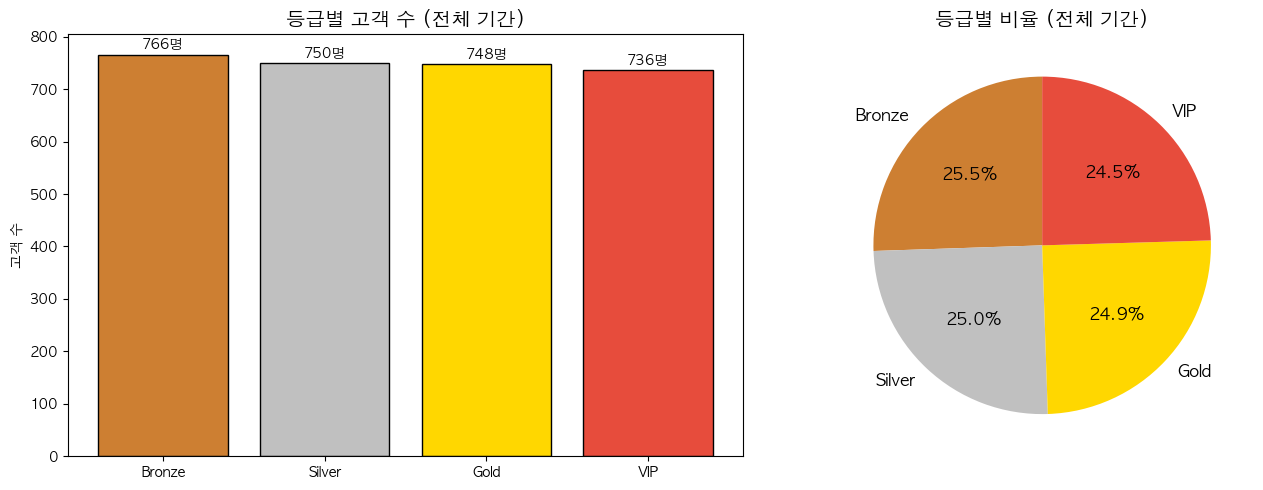

In [ ]:
# =============================================
# 시각화 - 등급별 고객 수 분포 (전체 기간)
# =============================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

grade_counts_all = rfm_all['Grade'].value_counts().sort_index()
colors = ['#cd7f32', '#c0c0c0', '#ffd700', '#e74c3c']

axes[0].bar(grade_counts_all.index, grade_counts_all.values, color=colors, edgecolor='black')
axes[0].set_title('등급별 고객 수 (전체 기간)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('고객 수')
for i, v in enumerate(grade_counts_all.values):
    axes[0].text(i, v + 10, f'{v}명', ha='center', fontweight='bold')

axes[1].pie(grade_counts_all.values, labels=grade_counts_all.index, colors=colors,
            autopct='%1.1f%%', startangle=90, textprops={'fontsize': 12})
axes[1].set_title('등급별 비율 (전체 기간)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('rfm_all_grade_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

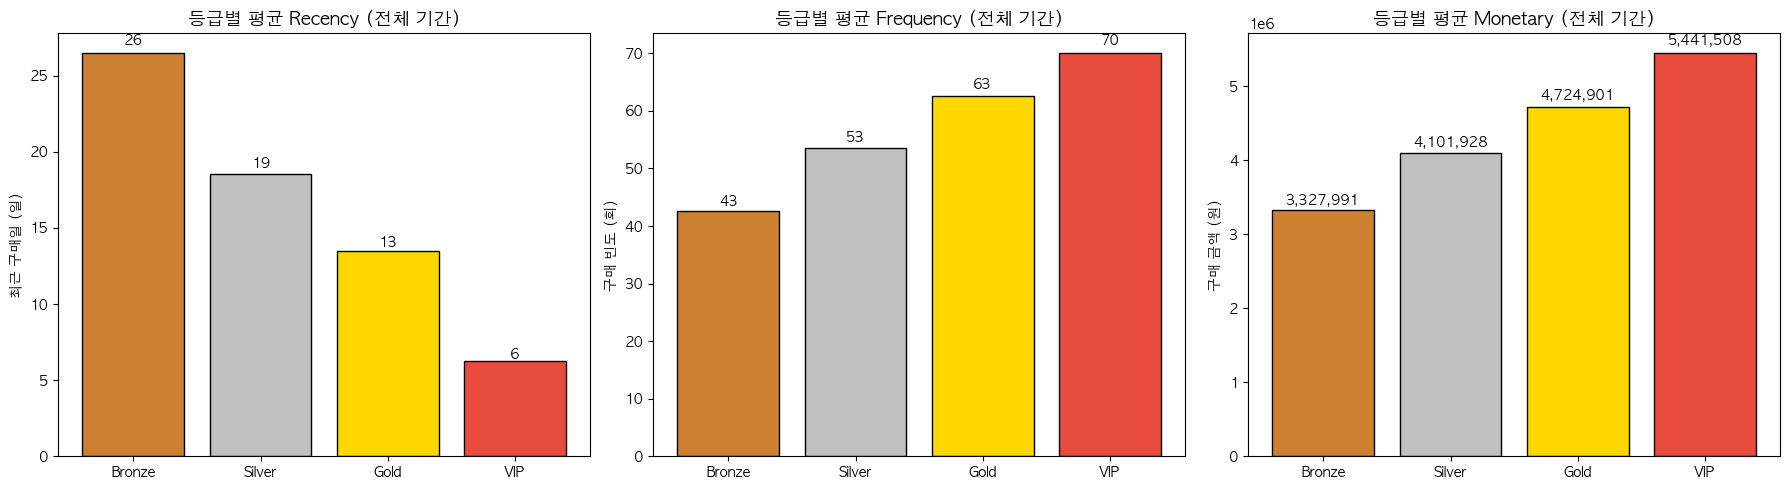

In [ ]:
# =============================================
# 시각화 - 등급별 R, F, M 평균 비교 (전체 기간)
# =============================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
grade_order_all = ['Bronze', 'Silver', 'Gold', 'VIP']
colors = ['#cd7f32', '#c0c0c0', '#ffd700', '#e74c3c']

metrics = [('Recency', '최근 구매일 (일)'), 
           ('Frequency', '구매 빈도 (회)'), 
           ('Monetary', '구매 금액 (원)')]

for ax, (col, ylabel) in zip(axes, metrics):
    means = rfm_all.groupby('Grade', observed=True)[col].mean().reindex(grade_order_all)
    bars = ax.bar(grade_order_all, means.values, color=colors, edgecolor='black')
    ax.set_title(f'등급별 평균 {col} (전체 기간)', fontsize=13, fontweight='bold')
    ax.set_ylabel(ylabel)
    for bar, val in zip(bars, means.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + bar.get_height()*0.02,
                f'{val:,.0f}', ha='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig('rfm_all_grade_rfm_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

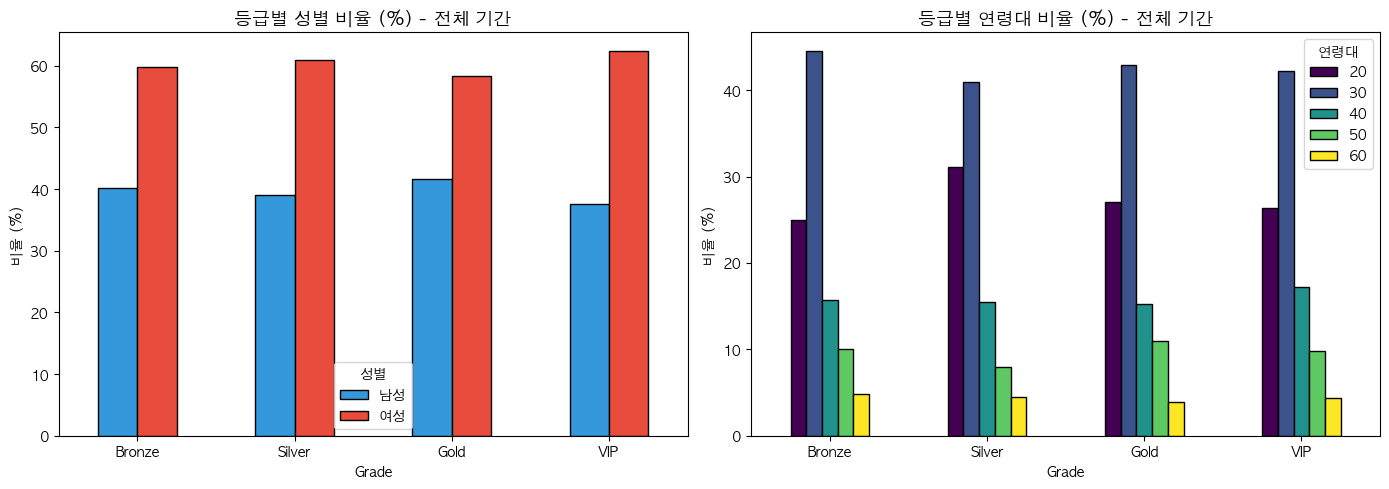

=== 등급별 성별 비율 (%) ===
Gender    남성    여성
Grade             
Bronze  40.2  59.8
Silver  39.1  60.9
Gold    41.7  58.3
VIP     37.6  62.4

=== 등급별 연령대 비율 (%) ===
AgeGroup    20    30    40    50   60
Grade                                
Bronze    24.9  44.5  15.7  10.1  4.8
Silver    31.1  40.9  15.5   8.0  4.5
Gold      27.0  42.9  15.2  11.0  3.9
VIP       26.4  42.3  17.3   9.8  4.3


In [ ]:
# =============================================
# 시각화 - 등급별 인구통계 특성 (전체 기간)
# =============================================

customer_info_all = df.groupby('idUser').agg(
    Gender=('Gender', 'first'),
    AgeGroup=('AgeGroup', 'first')
).reset_index()

rfm_all_demo = rfm_all.merge(customer_info_all, on='idUser')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ct_gender_all = pd.crosstab(rfm_all_demo['Grade'], rfm_all_demo['Gender'], normalize='index') * 100
ct_gender_all = ct_gender_all.reindex(grade_order_all)
ct_gender_all.plot(kind='bar', ax=axes[0], color=['#3498db', '#e74c3c'], edgecolor='black')
axes[0].set_title('등급별 성별 비율 (%) - 전체 기간', fontsize=13, fontweight='bold')
axes[0].set_ylabel('비율 (%)')
axes[0].set_xticklabels(grade_order_all, rotation=0)
axes[0].legend(title='성별')

ct_age_all = pd.crosstab(rfm_all_demo['Grade'], rfm_all_demo['AgeGroup'], normalize='index') * 100
ct_age_all = ct_age_all.reindex(grade_order_all)
ct_age_all.plot(kind='bar', ax=axes[1], colormap='viridis', edgecolor='black')
axes[1].set_title('등급별 연령대 비율 (%) - 전체 기간', fontsize=13, fontweight='bold')
axes[1].set_ylabel('비율 (%)')
axes[1].set_xticklabels(grade_order_all, rotation=0)
axes[1].legend(title='연령대')

plt.tight_layout()
plt.savefig('rfm_all_grade_demographics.png', dpi=150, bbox_inches='tight')
plt.show()

print("=== 등급별 성별 비율 (%) ===")
print(ct_gender_all.round(1))
print(f"\n=== 등급별 연령대 비율 (%) ===")
print(ct_age_all.round(1))

In [ ]:
# =============================================
# 결과 저장 (전체 기간)
# =============================================

rfm_all.to_csv('../customer_rfm_all.csv', index=False, encoding='cp949')
print(f"전체 기간 RFM 결과 저장 완료: customer_rfm_all.csv ({len(rfm_all):,}명)")
print(f"\n=== 저장된 컬럼 ===")
print(rfm_all.columns.tolist())
print(f"\n=== 최종 결과 미리보기 ===")
rfm_all[['idUser', 'Recency', 'Frequency', 'Monetary', 'R_score', 'F_score', 'M_score', 
         'weighted_score', 'Grade']].head(10)

전체 기간 RFM 결과 저장 완료: customer_rfm_all.csv (3,000명)

=== 저장된 컬럼 ===
['idUser', 'Recency', 'Frequency', 'Monetary', 'R_score', 'F_score', 'M_score', 'weighted_score', 'Grade']

=== 최종 결과 미리보기 ===


,idUser,Recency,Frequency,Monetary,R_score,F_score,M_score,weighted_score,Grade
0,U10001,4,69,5414990,4,5,5,4.65,VIP
1,U10002,25,53,3946750,2,2,2,2.00,Bronze
2,U10003,8,53,4759100,3,2,4,2.75,Silver
3,U10004,26,33,2498420,2,1,1,1.35,Bronze
4,U10005,41,78,5563770,1,5,5,3.60,Gold
5,U10006,4,70,5663150,4,5,5,4.65,VIP
6,U10007,31,71,5688790,1,5,5,3.60,Gold
7,U10008,5,65,5368790,4,4,5,4.20,VIP
8,U10009,19,25,2054270,2,1,1,1.35,Bronze
9,U10010,2,30,2089450,5,1,1,2.40,Silver


# 전체 기간(3년) + PCA 기반 CV 가중치 — 5점 체계, 4등급

In [19]:
# =============================================
# Step 1: 전체 기간 RFM 지표 계산 (PCA 버전)
# =============================================
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# 전체 데이터 기반 RFM 집계
rfm_pca = df.groupby('idUser').agg(
    Recency=('OrderDT', lambda x: (snapshot_date - x.max()).days),
    Frequency=('idOrder', 'nunique'),
    Monetary=('Price', 'sum')
).reset_index()

print(f"=== 전체 기간 RFM 기술통계량 (PCA 버전) ===")
print(f"분석 대상 고객 수: {len(rfm_pca):,}명")
print(f"분석 기간: {df['OrderDT'].min().date()} ~ {df['OrderDT'].max().date()}\n")
print(rfm_pca[['Recency', 'Frequency', 'Monetary']].describe().round(2))

=== 전체 기간 RFM 기술통계량 (PCA 버전) ===
분석 대상 고객 수: 3,000명
분석 기간: 2023-01-02 ~ 2025-12-29

       Recency  Frequency    Monetary
count  3000.00    3000.00     3000.00
mean     16.30      57.01  4388287.82
std      18.16      12.99   994365.45
min       0.00       9.00   792360.00
25%       4.00      49.00  3739295.00
50%      11.00      60.00  4459500.00
75%      21.00      66.00  5081795.00
max     193.00      90.00  7432080.00


In [20]:
# =============================================
# Step 2: CV 측정 및 PCA 기반 가중치 산출
# =============================================

# 2-1. CV(변동계수) 확인
cv_r = rfm_pca['Recency'].std() / rfm_pca['Recency'].mean()
cv_f = rfm_pca['Frequency'].std() / rfm_pca['Frequency'].mean()
cv_m = rfm_pca['Monetary'].std() / rfm_pca['Monetary'].mean()

print("=== 변동계수(CV) ===")
print(f"Recency  CV: {cv_r:.4f}")
print(f"Frequency CV: {cv_f:.4f}")
print(f"Monetary  CV: {cv_m:.4f}")

# 2-2. 표준화
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_pca[['Recency', 'Frequency', 'Monetary']])

# 2-3. PCA 수행 (3개 주성분 모두 추출)
pca = PCA(n_components=3)
pca.fit(rfm_scaled)

print(f"\n=== PCA 결과 ===")
print(f"설명 분산 비율: {pca.explained_variance_ratio_.round(4)}")
print(f"누적 설명 분산: {pca.explained_variance_ratio_.cumsum().round(4)}")
print(f"\n주성분 로딩(Components):")
loading_df = pd.DataFrame(
    pca.components_,
    columns=['Recency', 'Frequency', 'Monetary'],
    index=[f'PC{i+1}' for i in range(3)]
)
print(loading_df.round(4))

# 2-4. 가중치 산출: 각 변수별로 |로딩| × 설명분산비율 합산
weights_raw = np.zeros(3)
for i in range(3):
    weights_raw += np.abs(pca.components_[i]) * pca.explained_variance_ratio_[i]

# 정규화 (합 = 1)
weights_pca = weights_raw / weights_raw.sum()

w_r_pca, w_f_pca, w_m_pca = weights_pca

print(f"\n=== PCA 기반 가중치 (정규화) ===")
print(f"Recency  가중치: {w_r_pca:.4f}")
print(f"Frequency 가중치: {w_f_pca:.4f}")
print(f"Monetary  가중치: {w_m_pca:.4f}")
print(f"합계: {weights_pca.sum():.4f}")

=== 변동계수(CV) ===
Recency  CV: 1.1144
Frequency CV: 0.2279
Monetary  CV: 0.2266

=== PCA 결과 ===
설명 분산 비율: [0.6499 0.3288 0.0213]
누적 설명 분산: [0.6499 0.9787 1.    ]

주성분 로딩(Components):
     Recency  Frequency  Monetary
PC1  -0.1192     0.7016    0.7025
PC2   0.9928     0.0913    0.0773
PC3   0.0099    -0.7066    0.7075

=== PCA 기반 가중치 (정규화) ===
Recency  가중치: 0.2882
Frequency 가중치: 0.3573
Monetary  가중치: 0.3544
합계: 1.0000


In [21]:
# =============================================
# Step 3: RFM 점수 부여 (1~5점, 5분위수 기반)
# =============================================

# R: 낮을수록(최근) 좋으므로 역순
rfm_pca['R_score'] = pd.qcut(rfm_pca['Recency'], q=5, labels=[5, 4, 3, 2, 1], duplicates='drop').astype(int)

# F: 높을수록 좋으므로 정순
rfm_pca['F_score'] = pd.qcut(rfm_pca['Frequency'], q=5, labels=[1, 2, 3, 4, 5], duplicates='drop').astype(int)

# M: 높을수록 좋으므로 정순
rfm_pca['M_score'] = pd.qcut(rfm_pca['Monetary'], q=5, labels=[1, 2, 3, 4, 5], duplicates='drop').astype(int)

print("=== RFM 점수 분포 (1~5점) ===")
for col in ['R_score', 'F_score', 'M_score']:
    print(f"\n{col}:")
    print(rfm_pca[col].value_counts().sort_index())

=== RFM 점수 분포 (1~5점) ===

R_score:
R_score
1    545
2    648
3    561
4    645
5    601
Name: count, dtype: int64

F_score:
F_score
1    645
2    586
3    605
4    620
5    544
Name: count, dtype: int64

M_score:
M_score
1    600
2    600
3    601
4    599
5    600
Name: count, dtype: int64


In [ ]:
# # =============================================
# # Step 4: PCA 가중치 적용 및 4등급 분류
# # =============================================

# # 가중 점수 계산
# rfm_pca['weighted_score'] = (
#     rfm_pca['R_score'] * w_r_pca + 
#     rfm_pca['F_score'] * w_f_pca + 
#     rfm_pca['M_score'] * w_m_pca
# )

# # 4분위로 등급 분류
# rfm_pca['Grade'] = pd.qcut(
#     rfm_pca['weighted_score'], q=4, 
#     labels=['Bronze', 'Silver', 'Gold', 'VIP'], duplicates='drop'
# )

# print(f"=== PCA 기반 가중치 ===")
# print(f"R: {w_r_pca:.4f}, F: {w_f_pca:.4f}, M: {w_m_pca:.4f}")
# print(f"\n가중 점수 범위: {rfm_pca['weighted_score'].min():.2f} ~ {rfm_pca['weighted_score'].max():.2f}")
# print(f"가중 점수 평균: {rfm_pca['weighted_score'].mean():.2f}")
# print(f"가중 점수 중앙값: {rfm_pca['weighted_score'].median():.2f}")
# print(f"\n=== 등급별 고객 수 ===")
# print(rfm_pca['Grade'].value_counts().sort_index())
# print(f"\n=== 등급별 RFM 평균 ===")
# print(rfm_pca.groupby('Grade', observed=True)[['Recency', 'Frequency', 'Monetary']].mean().round(2))

=== PCA 기반 가중치 ===
R: 0.2882, F: 0.3573, M: 0.3544

가중 점수 범위: 1.00 ~ 5.00
가중 점수 평균: 2.99
가중 점수 중앙값: 2.93

=== 등급별 고객 수 ===
Grade
Bronze    827
Silver    678
Gold      760
VIP       735
Name: count, dtype: int64

=== 등급별 RFM 평균 ===
        Recency  Frequency    Monetary
Grade                                 
Bronze    23.71      41.21  3217676.06
Silver    16.57      54.84  4165578.01
Gold      17.70      63.62  4834523.97
VIP        6.25      69.95  5449449.31


In [22]:
# =============================================
# Step 4: PCA 가중치 적용 및 4등급 분류 (방법 C: 백분위수 기반)
# =============================================

# 4-1. 각 변수를 백분위수로 변환 (0~100)
rfm_pca['R_percentile'] = rfm_pca['Recency'].rank(pct=True) * 100
rfm_pca['F_percentile'] = rfm_pca['Frequency'].rank(pct=True) * 100
rfm_pca['M_percentile'] = rfm_pca['Monetary'].rank(pct=True) * 100

# ⚠️ Recency는 역방향 (낮을수록 좋음)
rfm_pca['R_percentile'] = 100 - rfm_pca['R_percentile']

# 4-2. PCA 가중치를 적용한 종합 점수 (0~100)
rfm_pca['composite_score'] = (
    rfm_pca['R_percentile'] * w_r_pca +
    rfm_pca['F_percentile'] * w_f_pca +
    rfm_pca['M_percentile'] * w_m_pca
)

# 4-3. 고정 기준값으로 등급 분류
def assign_grade_percentile(score):
    """
    고정 기준값으로 등급 할당
    - VIP (80~100): 상위 20% 최우수 고객
    - Gold (60~79): 상위 20~40% 우수 고객
    - Silver (40~59): 중간 40~60% 일반 고객
    - Bronze (0~39): 하위 40% 잠재 고객
    """
    if score >= 80:
        return 'VIP'
    elif score >= 60:
        return 'Gold'
    elif score >= 40:
        return 'Silver'
    else:
        return 'Bronze'

rfm_pca['Grade'] = rfm_pca['composite_score'].apply(assign_grade_percentile)

# 4-4. 결과 출력
print(f"=== PCA 기반 가중치 ===")
print(f"Recency  가중치: {w_r_pca:.4f}")
print(f"Frequency 가중치: {w_f_pca:.4f}")
print(f"Monetary  가중치: {w_m_pca:.4f}")

print(f"\n=== 종합 점수 통계 ===")
print(f"점수 범위: {rfm_pca['composite_score'].min():.2f} ~ {rfm_pca['composite_score'].max():.2f}")
print(f"평균: {rfm_pca['composite_score'].mean():.2f}")
print(f"중앙값: {rfm_pca['composite_score'].median():.2f}")
print(f"표준편차: {rfm_pca['composite_score'].std():.2f}")

print(f"\n=== 등급별 고객 수 (실제 분포) ===")
grade_counts = rfm_pca['Grade'].value_counts().sort_index()
grade_pct = rfm_pca['Grade'].value_counts(normalize=True).sort_index() * 100
grade_summary = pd.DataFrame({
    '고객 수': grade_counts,
    '비율 (%)': grade_pct.round(2)
})
print(grade_summary)

print(f"\n=== 등급별 점수 범위 ===")
score_range = rfm_pca.groupby('Grade', observed=True)['composite_score'].agg(['min', 'max', 'mean'])
print(score_range.round(2))

print(f"\n=== 등급별 RFM 평균 ===")
rfm_by_grade = rfm_pca.groupby('Grade', observed=True)[['Recency', 'Frequency', 'Monetary']].mean()
print(rfm_by_grade.round(2))

print(f"\n=== 등급별 백분위수 평균 ===")
percentile_by_grade = rfm_pca.groupby('Grade', observed=True)[['R_percentile', 'F_percentile', 'M_percentile']].mean()
print(percentile_by_grade.round(2))

# 4-5. 등급별 상세 분석
print(f"\n=== 등급별 상세 분석 ===")
for grade in ['VIP', 'Gold', 'Silver', 'Bronze']:
    grade_data = rfm_pca[rfm_pca['Grade'] == grade]
    if len(grade_data) > 0:
        print(f"\n📊 {grade} 등급:")
        print(f"  고객 수: {len(grade_data)}명 ({len(grade_data)/len(rfm_pca)*100:.1f}%)")
        print(f"  종합점수: {grade_data['composite_score'].min():.1f}~{grade_data['composite_score'].max():.1f}")
        print(f"  Recency (최근방문일): {grade_data['Recency'].mean():.1f}일 (낮을수록 좋음)")
        print(f"  Frequency (구매빈도): {grade_data['Frequency'].mean():.1f}회")
        print(f"  Monetary (구매금액): {grade_data['Monetary'].mean():.0f}원")

=== PCA 기반 가중치 ===
Recency  가중치: 0.2882
Frequency 가중치: 0.3573
Monetary  가중치: 0.3544

=== 종합 점수 통계 ===
점수 범위: 0.27 ~ 98.69
평균: 50.01
중앙값: 49.63
표준편차: 22.41

=== 등급별 고객 수 (실제 분포) ===
        고객 수  비율 (%)
Grade               
Bronze  1082   36.07
Gold     759   25.30
Silver   852   28.40
VIP      307   10.23

=== 등급별 점수 범위 ===
          min    max   mean
Grade                      
Bronze   0.27  39.99  25.81
Gold    60.01  79.98  69.64
Silver  40.02  59.96  49.89
VIP     80.09  98.69  87.07

=== 등급별 RFM 평균 ===
        Recency  Frequency    Monetary
Grade                                 
Bronze    22.59      43.93  3407814.15
Gold      11.88      67.00  5156352.19
Silver    16.83      58.84  4457355.80
VIP        3.57      73.32  5753322.77

=== 등급별 백분위수 평균 ===
        R_percentile  F_percentile  M_percentile
Grade                                           
Bronze         38.75         20.61         20.54
Gold           56.00         75.18         75.13
Silver         48.26         50.51 

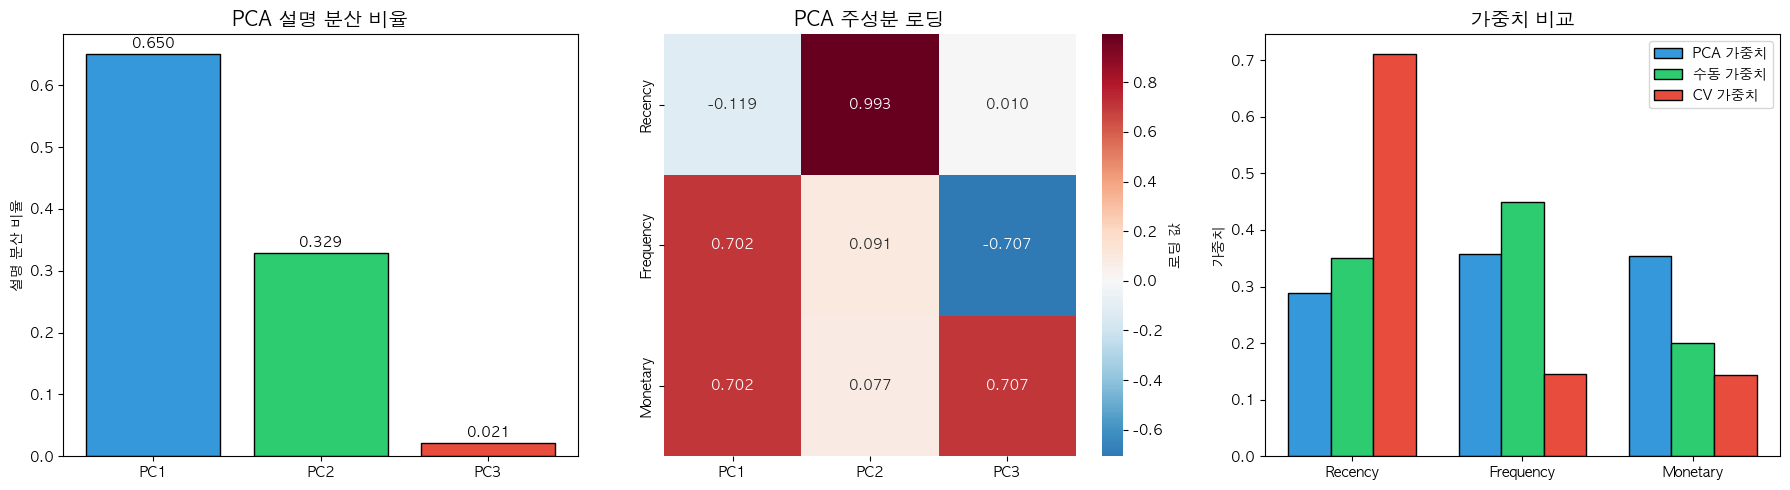

In [23]:
# =============================================
# Step 5-1: 시각화 - PCA 설명 분산 및 가중치 비교
# =============================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# (1) PCA 설명 분산 비율
pcs = [f'PC{i+1}' for i in range(3)]
axes[0].bar(pcs, pca.explained_variance_ratio_, color=['#3498db', '#2ecc71', '#e74c3c'], edgecolor='black')
axes[0].set_title('PCA 설명 분산 비율', fontsize=14, fontweight='bold')
axes[0].set_ylabel('설명 분산 비율')
for i, v in enumerate(pca.explained_variance_ratio_):
    axes[0].text(i, v + 0.01, f'{v:.3f}', ha='center', fontweight='bold')

# (2) PCA 로딩 히트맵
sns.heatmap(loading_df.T, annot=True, fmt='.3f', cmap='RdBu_r', center=0, 
            ax=axes[1], cbar_kws={'label': '로딩 값'})
axes[1].set_title('PCA 주성분 로딩', fontsize=14, fontweight='bold')

# (3) 가중치 비교 (PCA vs 수동 vs CV)
labels = ['Recency', 'Frequency', 'Monetary']
x = np.arange(len(labels))
width = 0.25

axes[2].bar(x - width, [w_r_pca, w_f_pca, w_m_pca], width, label='PCA 가중치', color='#3498db', edgecolor='black')
axes[2].bar(x, [0.35, 0.45, 0.20], width, label='수동 가중치', color='#2ecc71', edgecolor='black')
axes[2].bar(x + width, [w_r, w_f, w_m], width, label='CV 가중치', color='#e74c3c', edgecolor='black')
axes[2].set_title('가중치 비교', fontsize=14, fontweight='bold')
axes[2].set_xticks(x)
axes[2].set_xticklabels(labels)
axes[2].set_ylabel('가중치')
axes[2].legend()

plt.tight_layout()
plt.show()

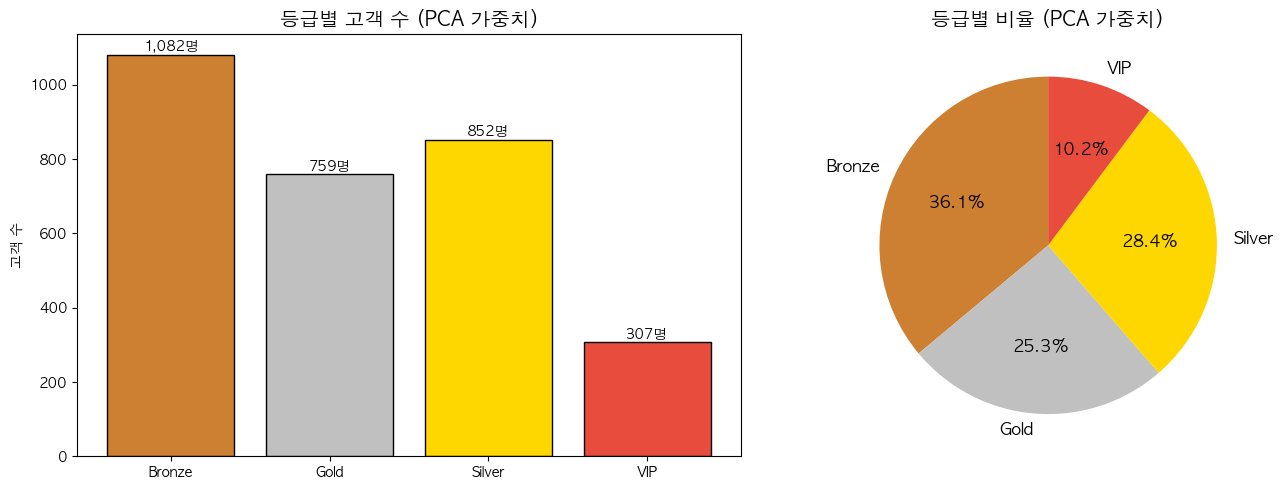

In [24]:
# =============================================
# Step 5-2: 시각화 - 등급별 고객 수 분포
# =============================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

grade_counts_pca = rfm_pca['Grade'].value_counts().sort_index()
colors = ['#cd7f32', '#c0c0c0', '#ffd700', '#e74c3c']

axes[0].bar(grade_counts_pca.index, grade_counts_pca.values, color=colors, edgecolor='black')
axes[0].set_title('등급별 고객 수 (PCA 가중치)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('고객 수')
for i, v in enumerate(grade_counts_pca.values):
    axes[0].text(i, v + 10, f'{v:,}명', ha='center', fontweight='bold')

# 등급별 비율 파이차트
axes[1].pie(grade_counts_pca.values, labels=grade_counts_pca.index, colors=colors,
            autopct='%1.1f%%', startangle=90, textprops={'fontsize': 12})
axes[1].set_title('등급별 비율 (PCA 가중치)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

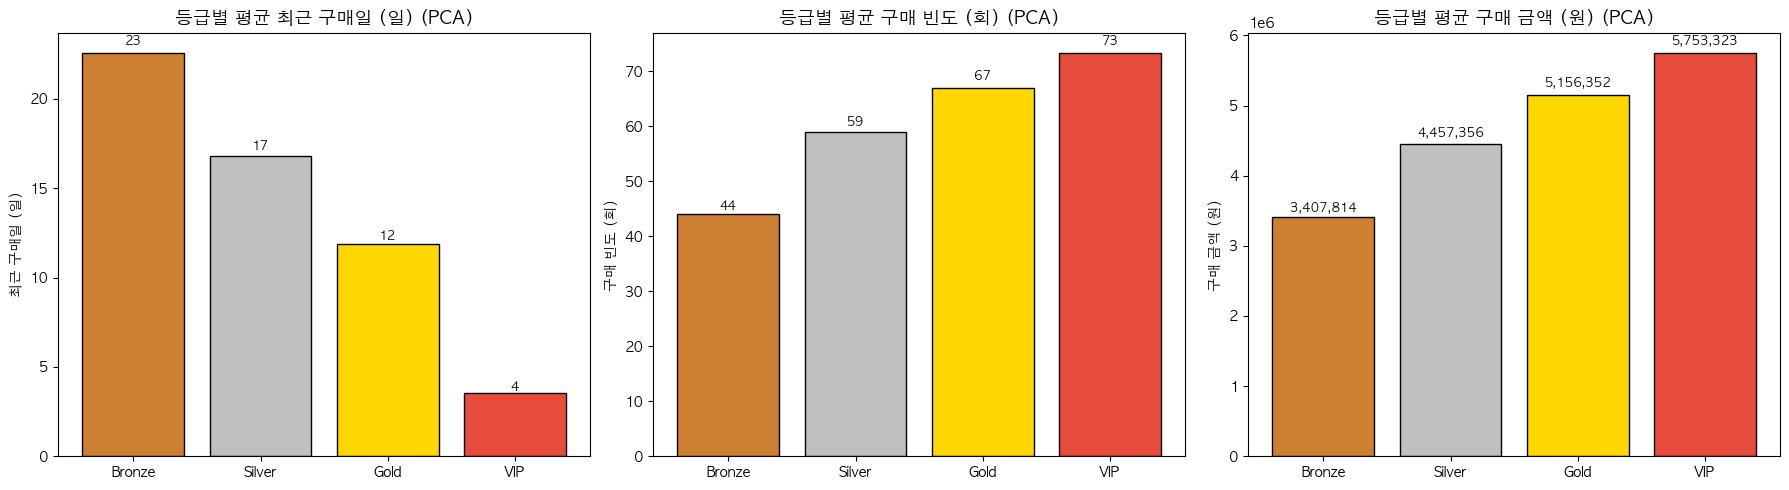

In [25]:
# =============================================
# Step 5-3: 시각화 - 등급별 R, F, M 평균 비교
# =============================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
grade_order_pca = ['Bronze', 'Silver', 'Gold', 'VIP']
colors = ['#cd7f32', '#c0c0c0', '#ffd700', '#e74c3c']

metrics = [('Recency', '최근 구매일 (일)'), 
           ('Frequency', '구매 빈도 (회)'), 
           ('Monetary', '구매 금액 (원)')]

for ax, (col, ylabel) in zip(axes, metrics):
    means = rfm_pca.groupby('Grade', observed=True)[col].mean().reindex(grade_order_pca)
    ax.bar(grade_order_pca, means.values, color=colors, edgecolor='black')
    ax.set_title(f'등급별 평균 {ylabel} (PCA)', fontsize=13, fontweight='bold')
    ax.set_ylabel(ylabel)
    for i, v in enumerate(means.values):
        ax.text(i, v + v * 0.02, f'{v:,.0f}', ha='center', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()

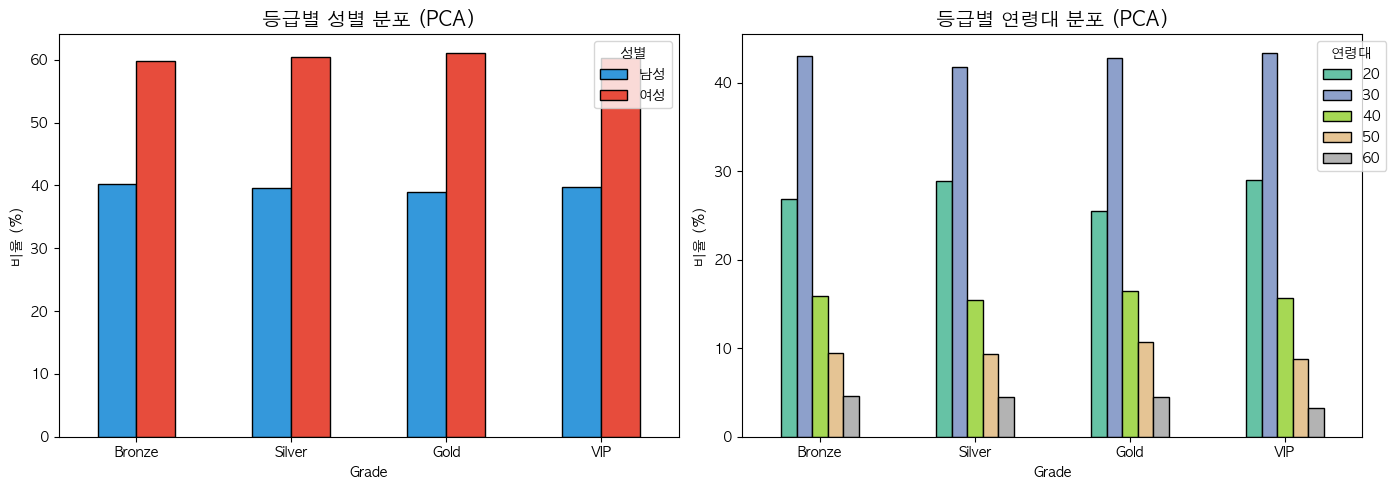

In [26]:
# =============================================
# Step 5-4: 시각화 - 등급별 인구통계 특성
# =============================================

customer_info_pca = df.groupby('idUser').agg(
    Gender=('Gender', 'first'),
    AgeGroup=('AgeGroup', 'first')
).reset_index()

rfm_pca_demo = rfm_pca.merge(customer_info_pca, on='idUser')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 등급별 성별 분포
ct_gender_pca = pd.crosstab(rfm_pca_demo['Grade'], rfm_pca_demo['Gender'], normalize='index') * 100
ct_gender_pca = ct_gender_pca.reindex(grade_order_pca)
ct_gender_pca.plot(kind='bar', ax=axes[0], color=['#3498db', '#e74c3c'], edgecolor='black')
axes[0].set_title('등급별 성별 분포 (PCA)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('비율 (%)')
axes[0].set_xticklabels(grade_order_pca, rotation=0)
axes[0].legend(title='성별')

# 등급별 연령대 분포
ct_age_pca = pd.crosstab(rfm_pca_demo['Grade'], rfm_pca_demo['AgeGroup'], normalize='index') * 100
ct_age_pca = ct_age_pca.reindex(grade_order_pca)
ct_age_pca.plot(kind='bar', ax=axes[1], edgecolor='black', cmap='Set2')
axes[1].set_title('등급별 연령대 분포 (PCA)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('비율 (%)')
axes[1].set_xticklabels(grade_order_pca, rotation=0)
axes[1].legend(title='연령대', bbox_to_anchor=(1.05, 1))

plt.tight_layout()
plt.show()

In [28]:
# =============================================
# Step 6: 결과 저장 (PCA 가중치 버전)
# =============================================

rfm_pca.to_csv('../customer_rfm_pca.csv', index=False, encoding='cp949')
print(f"PCA 기반 RFM 결과 저장 완료: customer_rfm_pca.csv ({len(rfm_pca):,}명)")
print(f"\n=== 저장된 컬럼 ===")
print(rfm_pca.columns.tolist())
print(f"\n=== 최종 결과 미리보기 ===")
rfm_pca[['idUser', 'Recency', 'Frequency', 'Monetary', 'R_score', 'F_score', 'M_score', 
         'composite_score', 'Grade']].head(10)

PCA 기반 RFM 결과 저장 완료: customer_rfm_pca.csv (3,000명)

=== 저장된 컬럼 ===
['idUser', 'Recency', 'Frequency', 'Monetary', 'R_score', 'F_score', 'M_score', 'R_percentile', 'F_percentile', 'M_percentile', 'composite_score', 'Grade']

=== 최종 결과 미리보기 ===


,idUser,Recency,Frequency,Monetary,R_score,F_score,M_score,composite_score,Grade
0,U10001,4,69,5414990,4,5,5,82.035707,VIP
1,U10002,25,53,3946750,2,2,2,28.946197,Bronze
2,U10003,8,53,4759100,3,2,4,50.879667,Silver
3,U10004,26,33,2498420,2,1,1,8.385254,Bronze
4,U10005,41,78,5563770,1,5,5,68.979681,Gold
5,U10006,4,70,5663150,4,5,5,85.049591,VIP
6,U10007,31,71,5688790,1,5,5,68.458002,Gold
7,U10008,5,65,5368790,4,4,5,75.426332,Gold
8,U10009,19,25,2054270,2,1,1,9.725641,Bronze
9,U10010,2,30,2089450,5,1,1,27.226545,Bronze


=== 분위수 경계값 ===
Recency  (20/40/60/80%): [ 3.  7. 13. 26.]
Frequency (20/40/60/80%): [46. 56. 62. 68.]
Monetary  (20/40/60/80%): [3568666. 4213840. 4696480. 5242442.]


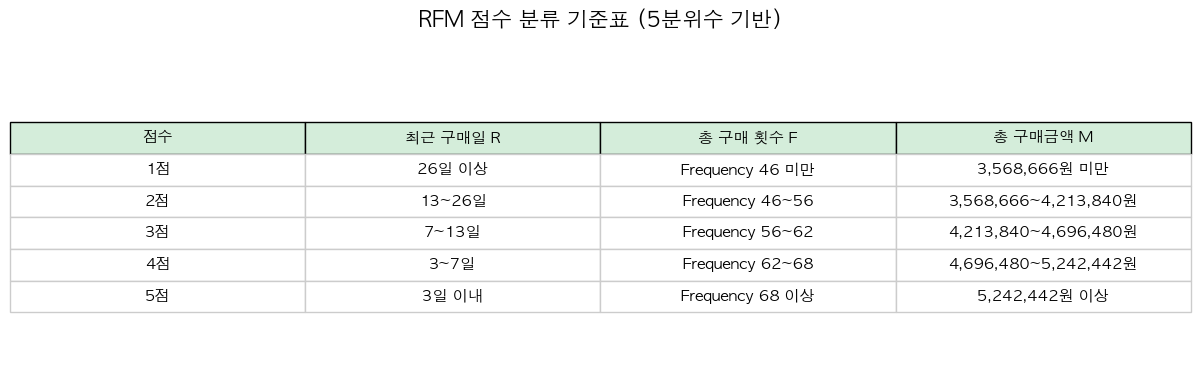

In [18]:
# =============================================
# RFM 점수 분류 기준표
# =============================================

# 실제 데이터 기반 분위수 경계값 확인
r_quantiles = rfm_pca['Recency'].quantile([0.2, 0.4, 0.6, 0.8]).values
f_quantiles = rfm_pca['Frequency'].quantile([0.2, 0.4, 0.6, 0.8]).values
m_quantiles = rfm_pca['Monetary'].quantile([0.2, 0.4, 0.6, 0.8]).values

print("=== 분위수 경계값 ===")
print(f"Recency  (20/40/60/80%): {r_quantiles}")
print(f"Frequency (20/40/60/80%): {f_quantiles}")
print(f"Monetary  (20/40/60/80%): {m_quantiles}")

# 점수 분류 기준표 시각화
fig, ax = plt.subplots(figsize=(12, 4))
ax.axis('off')

# 테이블 데이터
col_labels = ['점수', '최근 구매일 R', '총 구매 횟수 F', '총 구매금액 M']
table_data = [
    ['1점', f'{r_quantiles[3]:.0f}일 이상', f'Frequency {f_quantiles[0]:.0f} 미만', f'{m_quantiles[0]:,.0f}원 미만'],
    ['2점', f'{r_quantiles[2]:.0f}~{r_quantiles[3]:.0f}일', f'Frequency {f_quantiles[0]:.0f}~{f_quantiles[1]:.0f}', f'{m_quantiles[0]:,.0f}~{m_quantiles[1]:,.0f}원'],
    ['3점', f'{r_quantiles[1]:.0f}~{r_quantiles[2]:.0f}일', f'Frequency {f_quantiles[1]:.0f}~{f_quantiles[2]:.0f}', f'{m_quantiles[1]:,.0f}~{m_quantiles[2]:,.0f}원'],
    ['4점', f'{r_quantiles[0]:.0f}~{r_quantiles[1]:.0f}일', f'Frequency {f_quantiles[2]:.0f}~{f_quantiles[3]:.0f}', f'{m_quantiles[2]:,.0f}~{m_quantiles[3]:,.0f}원'],
    ['5점', f'{r_quantiles[0]:.0f}일 이내', f'Frequency {f_quantiles[3]:.0f} 이상', f'{m_quantiles[3]:,.0f}원 이상'],
]

table = ax.table(cellText=table_data, colLabels=col_labels, loc='center', cellLoc='center')
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 1.8)

# 헤더 스타일
for j in range(len(col_labels)):
    table[0, j].set_facecolor('#d4edda')
    table[0, j].set_text_props(fontweight='bold')

# 셀 스타일
for i in range(1, len(table_data) + 1):
    for j in range(len(col_labels)):
        table[i, j].set_facecolor('#ffffff')
        table[i, j].set_edgecolor('#cccccc')

ax.set_title('RFM 점수 분류 기준표 (5분위수 기반)', fontsize=15, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()